Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

STATYSTYKI ZBIORU TRENINGOWEGO
Rozkład kategorii ataków i ruchu bezpiecznego (attack_cat):
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64

Podział ruchu (label: 0 - bezpieczny, 1 - atak):
label
1    119341
0     56000
Name: count, dtype: int64

STATYSTYKI ZBIORU TESTOWEGO
Rozkład kategorii ataków i ruchu bezpiecznego (attack_cat):
attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64

Podział ruchu (label: 0 - bez

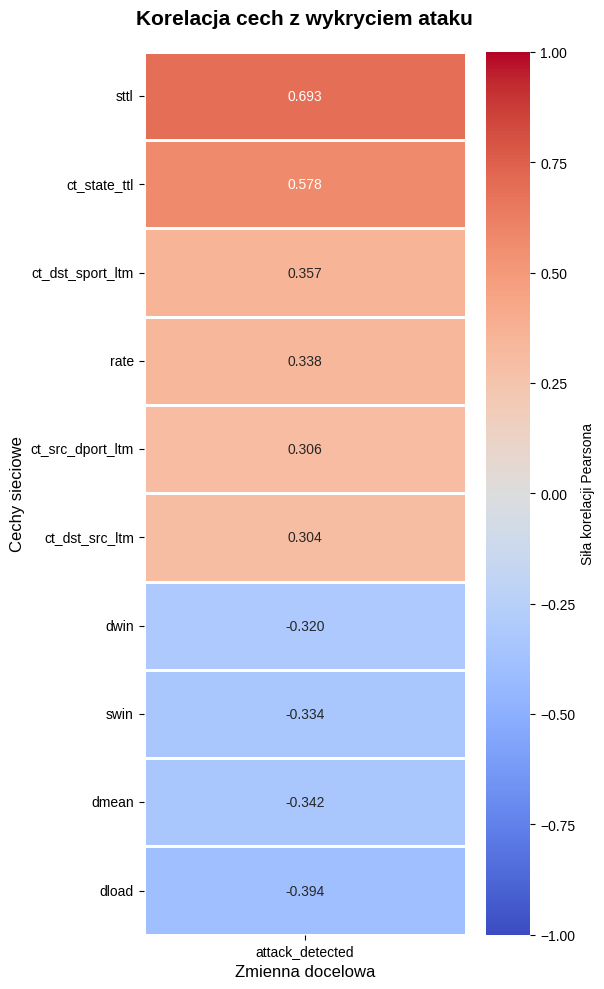

In [5]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

!wget -q -O /content/UNSW_NB15_training-set.csv https://raw.githubusercontent.com/Nir-J/ML-Projects/master/UNSW-Network_Packet_Classification/UNSW_NB15_training-set.csv
!wget -q -O /content/UNSW_NB15_testing-set.csv https://raw.githubusercontent.com/Nir-J/ML-Projects/master/UNSW-Network_Packet_Classification/UNSW_NB15_testing-set.csv

train_path = '/content/UNSW_NB15_training-set.csv'
test_path = '/content/UNSW_NB15_testing-set.csv'

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

assert df_train.shape[0] == 175341, f"Błąd rozmiaru treningowego! Jest {df_train.shape[0]}"
assert df_test.shape[0] == 82332, f"Błąd rozmiaru testowego! Jest {df_test.shape[0]}"


print("\nSTATYSTYKI ZBIORU TRENINGOWEGO")
print("Rozkład kategorii ataków i ruchu bezpiecznego (attack_cat):")
print(df_train['attack_cat'].fillna('Normal').value_counts())
print("\nPodział ruchu (label: 0 - bezpieczny, 1 - atak):")
print(df_train['label'].value_counts())

print("\nSTATYSTYKI ZBIORU TESTOWEGO")
print("Rozkład kategorii ataków i ruchu bezpiecznego (attack_cat):")
print(df_test['attack_cat'].fillna('Normal').value_counts())
print("\nPodział ruchu (label: 0 - bezpieczny, 1 - atak):")
print(df_test['label'].value_counts())


df_train['is_train_set'] = 1
df_test['is_train_set'] = 0
df_all = pd.concat([df_train, df_test], ignore_index=True)

df_all['service'] = df_all['service'].replace('-', 'Unknown')
df_all = df_all.drop(columns=['id', 'attack_cat'])

kolumny_do_zakodowania = ['proto', 'service', 'state']
df_all_cleaned = pd.get_dummies(df_all, columns=kolumny_do_zakodowania, drop_first=True)

train_cleaned = df_all_cleaned[df_all_cleaned['is_train_set'] == 1].drop(columns=['is_train_set'])
test_cleaned = df_all_cleaned[df_all_cleaned['is_train_set'] == 0].drop(columns=['is_train_set'])

X_train = train_cleaned.drop(columns=['label'])
y_train = train_cleaned['label']

X_test = test_cleaned.drop(columns=['label'])
y_test = test_cleaned['label']

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print(f"\nRozmiar zbioru treningowego po transformacji: {X_train_scaled.shape}")
print(f"Rozmiar zbioru testowego po transformacji: {X_test_scaled.shape}")

folder_path = '/content/drive/MyDrive/Colab Notebooks/cybersec_ml_mgr/UNSW-NB15-test/'
os.makedirs(folder_path, exist_ok=True)


print("\nANALIZA KORELACJI (TOP 10 CECH VS ZMIENNA DOCELOWA)")

df_analiza = df_train.select_dtypes(include=[np.number]).copy()
df_analiza = df_analiza.rename(columns={'label': 'attack_detected'})

if 'id' in df_analiza.columns:
    df_analiza = df_analiza.drop(columns=['id'])

korelacja_pelna = df_analiza.corr()[['attack_detected']].drop('attack_detected')

korelacja_pelna['abs_corr'] = korelacja_pelna['attack_detected'].abs()
top_10_cech = korelacja_pelna.sort_values(by='abs_corr', ascending=False).head(10)

korelacja_z_celem = top_10_cech[['attack_detected']].sort_values(by='attack_detected', ascending=False)
print("\n", korelacja_z_celem)

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Liberation Sans', 'DejaVu Sans', 'Arial', 'Calibri']

plt.figure(figsize=(6, 10))

sns.heatmap(korelacja_z_celem,
            annot=True,
            fmt='.3f',
            cmap='coolwarm',
            vmin=-1,
            vmax=1,
            linewidths=1,
            linecolor='white',
            cbar_kws={'label': 'Siła korelacji Pearsona'})

plt.title('Korelacja cech z wykryciem ataku', fontsize=15, pad=20, weight='bold')
plt.ylabel('Cechy sieciowe', fontsize=12)
plt.xlabel('Zmienna docelowa', fontsize=12)

plt.tight_layout()
plt.savefig(folder_path + 'korelacja_z_wykryciem_ataku.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()


X_train_scaled.to_csv(folder_path + 'X_train.csv', index=False)
X_test_scaled.to_csv(folder_path + 'X_test.csv', index=False)
y_train.to_csv(folder_path + 'y_train.csv', index=False)
y_test.to_csv(folder_path + 'y_test.csv', index=False)